# Project 12 — Radon (varying-intercept multilevel) + group predictor + LOGO-CV

**Tier 3 · Multilevel** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P12_radon-multilevel/P12_radon-multilevel_12-06-2026_Opus48.ipynb)

The textbook multilevel regression (Gelman & Hill 2007): household **radon** by **floor**, with a
**varying intercept per county** and a **county-level predictor** (soil uranium). New skills: the
**no-pooling / complete-pooling / partial-pooling** spectrum (see small counties shrink), the
**non-centered** parameterization for the county effects, and the honest cross-validation for grouped
data — **leave-one-GROUP-out CV (LOGO)**, contrasted with naive leave-one-row-out LOO. Tier 3 adds **SBC**.

## Learning objectives
1. Build a varying-intercept model `log_radon ~ a_county[county] + b_floor·floor` with a **group predictor** `a_county ~ Normal(g0 + g_u·u_county, sigma_a)`.
2. Use the **non-centered** parameterization for `a_county` to avoid the funnel.
3. Show **shrinkage**: small-n counties pulled toward the uranium-predicted line.
4. Demonstrate **LOGO-CV** on ≥3 held-out counties and explain why it, not naive LOO, is honest here.
5. Run **SBC** on `b_floor` and confirm calibration.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 12
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Data load — Minnesota radon (`,`-delimited)

In [2]:
URL = "https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/radon.csv"
CACHE = "data/radon.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=40).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw)); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE)
# county-level uranium predictor: Uppm is constant within county; use log
df["log_uranium"] = np.log(df["Uppm"].values)
print("shape:", df.shape, "| columns used: log_radon, floor, county, county_code, log_uranium")
df[["county","county_code","floor","log_radon","Uppm","log_uranium"]].head()

loaded from raw URL
shape: (919, 31) | columns used: log_radon, floor, county, county_code, log_uranium


,county,county_code,floor,log_radon,Uppm,log_uranium
0,AITKIN,0,1.0,0.832909,0.502054,-0.689048
1,AITKIN,0,0.0,0.832909,0.502054,-0.689048
2,AITKIN,0,0.0,1.098612,0.502054,-0.689048
3,AITKIN,0,0.0,0.095310,0.502054,-0.689048
4,ANOKA,1,0.0,1.163151,0.428565,-0.847313


## Stage 1–2 — Question & EDA
**Question:** how much lower is radon on the first floor than the basement, once we allow each county its
own baseline and account for county soil uranium? **Targets:** `b_floor` (floor effect) and `g_u`
(uranium slope on county baselines). The dataset has many counties with very few homes — the multilevel
model borrows strength across them.

919 homes in 85 counties | median homes/county 5 | counties with <=2 homes: 11


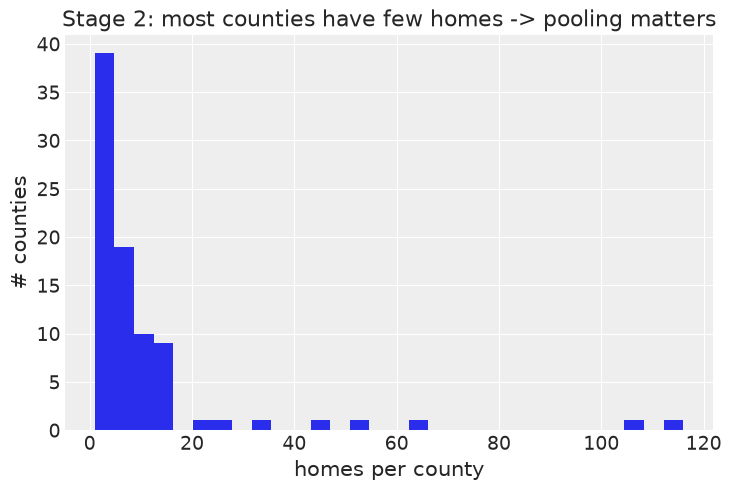

In [3]:
county_idx = df["county_code"].values.astype(int)
n_county = int(county_idx.max() + 1)
floor = df["floor"].values.astype(float)
y = df["log_radon"].values
# county-level uranium (one value per county)
u_county = df.groupby("county_code")["log_uranium"].first().sort_index().values
u_county_z = (u_county - u_county.mean()) / u_county.std()
counts = np.bincount(county_idx)
print(f"{len(df)} homes in {n_county} counties | median homes/county {np.median(counts):.0f} | "
      f"counties with <=2 homes: {(counts<=2).sum()}")
plt.hist(counts, bins=30); plt.xlabel("homes per county"); plt.ylabel("# counties")
plt.title("Stage 2: most counties have few homes -> pooling matters"); plt.show()

## Stage 0 — Fake-data parameter recovery [required]
Simulate from known `g0, g_u, b_floor, sigma_a, sigma`; fit the non-centered model; confirm recovery.

In [4]:
g0_t, gu_t, bf_t, sa_t, s_t = 1.4, 0.7, -0.65, 0.35, 0.75
a_county_t = rng.normal(g0_t + gu_t*u_county_z, sa_t)
y_sim = rng.normal(a_county_t[county_idx] + bf_t*floor, s_t)
with pm.Model() as m0:
    g0 = pm.Normal("g0", 0, 2); g_u = pm.Normal("g_u", 0, 2)
    b_floor = pm.Normal("b_floor", 0, 1)
    sigma_a = pm.HalfNormal("sigma_a", 1); sigma = pm.Exponential("sigma", 1)
    za = pm.Normal("za", 0, 1, shape=n_county)
    a_county = pm.Deterministic("a_county", g0 + g_u*u_county_z + sigma_a*za)
    pm.Normal("y", a_county[county_idx] + b_floor*floor, sigma, observed=y_sim)
    idata0 = pm.sample(800, tune=800, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["g0","g_u","b_floor","sigma_a","sigma"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat"]])
for name,tr in [("g0",g0_t),("g_u",gu_t),("b_floor",bf_t),("sigma_a",sa_t),("sigma",s_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [g0, g_u, b_floor, sigma_a, sigma, za]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 7 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


          mean  hdi_5%  hdi_95%  r_hat
g0       1.446   1.363    1.524    1.0
g_u      0.757   0.684    0.841    1.0
b_floor -0.609  -0.721   -0.502    1.0
sigma_a  0.301   0.231    0.372    1.0
sigma    0.749   0.719    0.779    1.0
g0 recovered: True
g_u recovered: True
b_floor recovered: True
sigma_a recovered: True
sigma recovered: True


## Stage 3 — Model specification (non-centered varying intercept + group predictor)
$$y_i \sim \mathrm{Normal}(a_{c[i]} + b_{\mathrm{floor}}\,\mathrm{floor}_i,\ \sigma),\quad
a_c = \gamma_0 + \gamma_u\,u_c + \sigma_a z_c,\ z_c\sim\mathrm{Normal}(0,1).$$
$$\gamma_0\sim\mathrm{Normal}(0,2),\ \gamma_u\sim\mathrm{Normal}(0,2),\ b_{\mathrm{floor}}\sim\mathrm{Normal}(0,1),\ \sigma_a\sim\mathrm{HalfNormal}(1),\ \sigma\sim\mathrm{Exponential}(1).$$
`u_c` is standardized county log-uranium. The **non-centered** `a_c = ... + sigma_a·z_c` avoids the funnel.

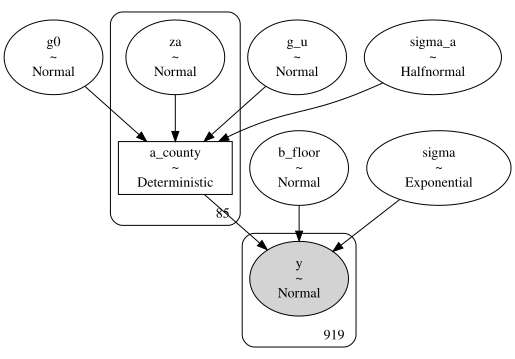

In [5]:
with pm.Model() as model:
    g0 = pm.Normal("g0", 0, 2); g_u = pm.Normal("g_u", 0, 2)
    b_floor = pm.Normal("b_floor", 0, 1)
    sigma_a = pm.HalfNormal("sigma_a", 1); sigma = pm.Exponential("sigma", 1)
    za = pm.Normal("za", 0, 1, shape=n_county)
    a_county = pm.Deterministic("a_county", g0 + g_u*u_county_z + sigma_a*za)
    mu = a_county[county_idx] + b_floor*floor
    pm.Normal("y", mu, sigma, observed=y)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: g0,g_u,sigma_a -> a_county -> y <- b_floor")

## Stage 4 — Prior predictive on the OUTCOME scale (log_radon)

Sampling: [b_floor, g0, g_u, sigma, sigma_a, y, za]


prior predictive log_radon: mean 0.02, sd 3.47, 1-99% [-9.1, 8.8]  (obs range [-2.3,3.9])


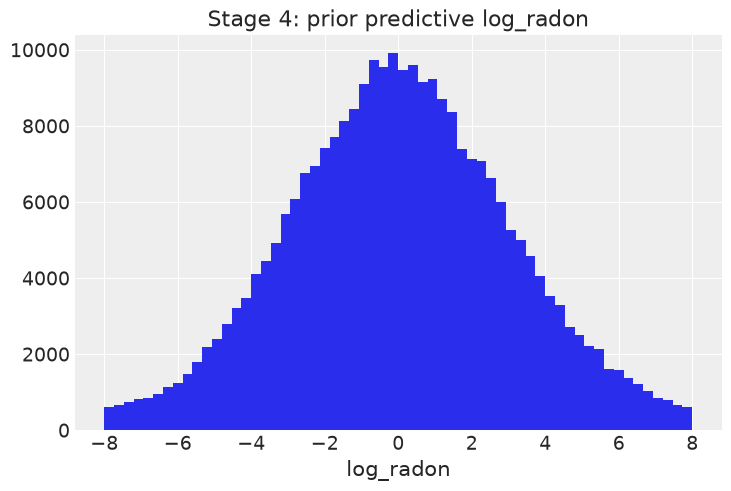

In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=300, random_seed=RANDOM_SEED)
ysim = pp.prior_predictive["y"].values.reshape(-1)
print(f"prior predictive log_radon: mean {ysim.mean():.2f}, sd {ysim.std():.2f}, "
      f"1-99% [{np.percentile(ysim,1):.1f}, {np.percentile(ysim,99):.1f}]  (obs range [{y.min():.1f},{y.max():.1f}])")
plt.hist(ysim, bins=60, range=(-8,8)); plt.title("Stage 4: prior predictive log_radon"); plt.xlabel("log_radon"); plt.show()

## Stage 5 — Fit

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.95,
                      random_seed=RANDOM_SEED, progressbar=False,
                      idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s | divergences: {int(idata.sample_stats.diverging.values.sum())}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [g0, g_u, b_floor, sigma_a, sigma, za]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


Sampling: [y]


wall-clock 11.7s | divergences: 0


## Stage 6 — Diagnostics

          mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
g0       1.504  0.036   1.434    1.573    1.0    2542.0    2652.0
g_u      0.267  0.034   0.204    0.333    1.0    2526.0    2719.0
b_floor -0.636  0.066  -0.764   -0.515    1.0    4292.0    3067.0
sigma_a  0.150  0.048   0.057    0.236    1.0    1169.0    1521.0
sigma    0.730  0.018   0.697    0.764    1.0    4015.0    3038.0

divergences: 0 | max r_hat: 1.000 | min ess_bulk: 1169 | BFMI: [0.76 0.7  0.74 0.7 ]


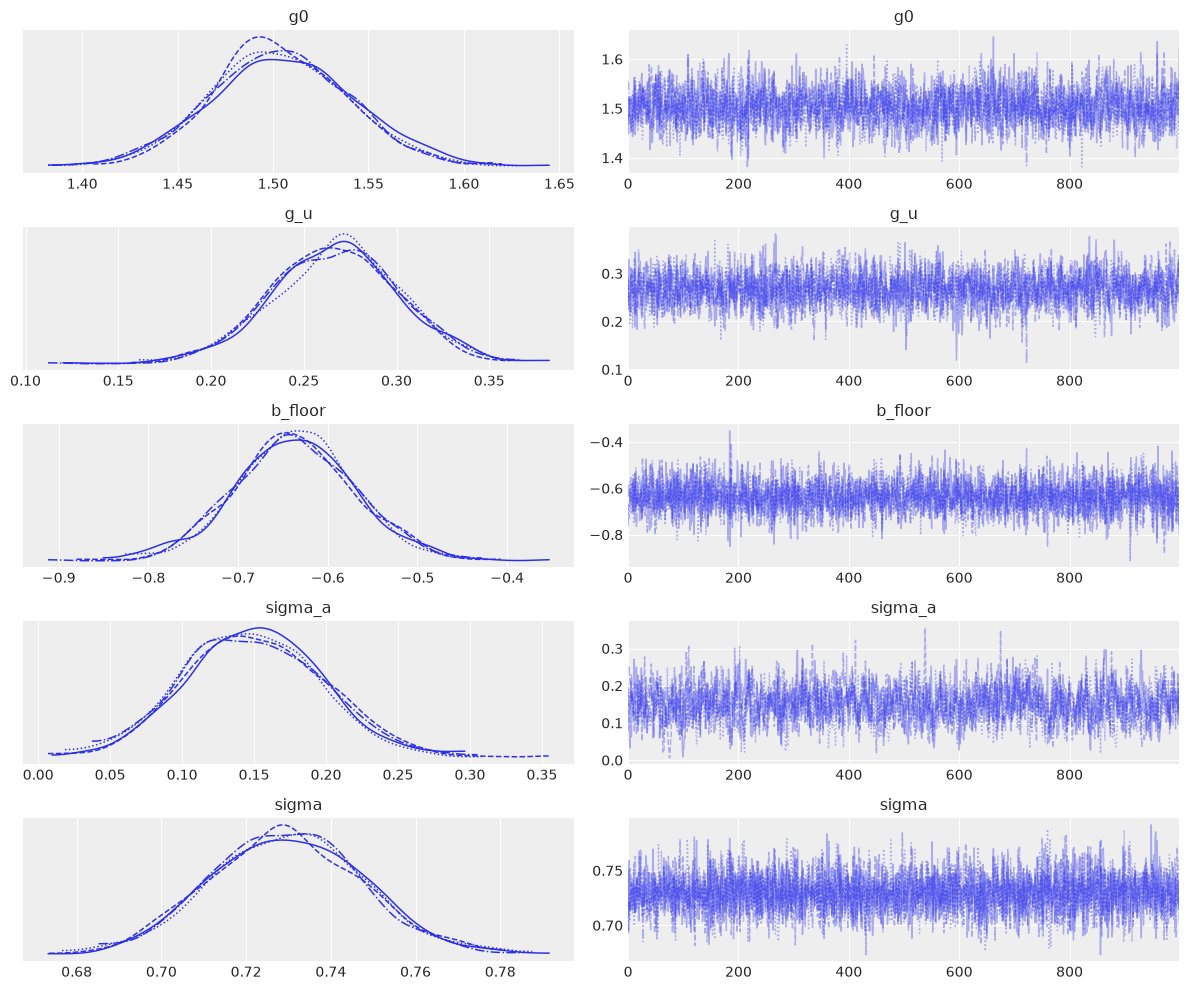

In [8]:
summ = az.summary(idata, var_names=["g0","g_u","b_floor","sigma_a","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print(f"\ndivergences: {int(idata.sample_stats.diverging.values.sum())} | "
      f"max r_hat: {summ['r_hat'].max():.3f} | min ess_bulk: {summ['ess_bulk'].min():.0f} | "
      f"BFMI: {np.round(az.bfmi(idata),2)}")
az.plot_trace(idata, var_names=["g0","g_u","b_floor","sigma_a","sigma"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation (original units) + the pooling spectrum
`b_floor` is the basement→first-floor change in log-radon; `g_u` is the uranium slope on county baselines.
We overlay **no-pooling** (per-county mean), **complete-pooling** (one global mean) and **partial-pooling**
(this model) to show small counties shrink toward the uranium-informed line.

b_floor = -0.636 (94% HDI -0.764 to -0.515) log-radon; x0.53 on radon scale (first floor vs basement)
g_u = 0.267 (94% HDI 0.204 to 0.333) per +1 SD county log-uranium


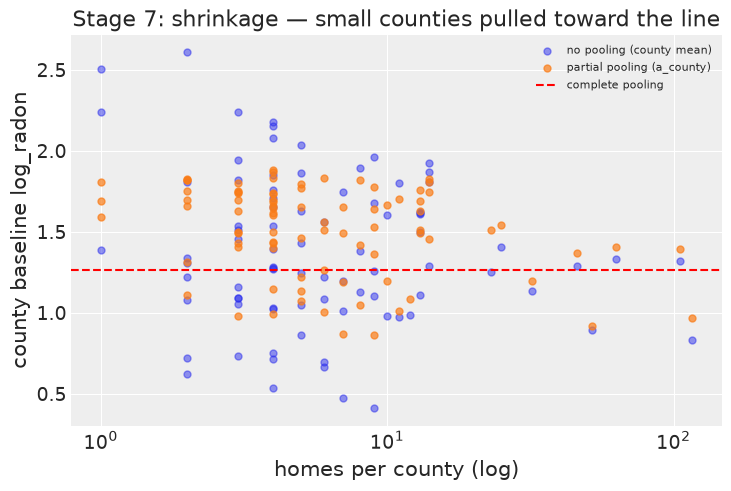

  county_code 49 (n=1): no-pool 2.50 -> partial 1.81 (toward 1.26)
  county_code 41 (n=1): no-pool 1.39 -> partial 1.59 (toward 1.26)
  county_code 81 (n=1): no-pool 2.24 -> partial 1.69 (toward 1.26)


In [9]:
bf = idata.posterior["b_floor"].mean().item()
bf_hdi = az.hdi(idata, var_names=["b_floor"], hdi_prob=0.94)["b_floor"].values
gu = idata.posterior["g_u"].mean().item()
gu_hdi = az.hdi(idata, var_names=["g_u"], hdi_prob=0.94)["g_u"].values
print(f"b_floor = {bf:.3f} (94% HDI {bf_hdi[0]:.3f} to {bf_hdi[1]:.3f}) log-radon; "
      f"x{np.exp(bf):.2f} on radon scale (first floor vs basement)")
print(f"g_u = {gu:.3f} (94% HDI {gu_hdi[0]:.3f} to {gu_hdi[1]:.3f}) per +1 SD county log-uranium")
# shrinkage plot
a_part = idata.posterior["a_county"].mean(dim=["chain","draw"]).values
nopool = np.array([y[county_idx==c].mean() if (county_idx==c).any() else np.nan for c in range(n_county)])
comp = y.mean()
plt.scatter(counts, nopool, s=25, alpha=.5, label="no pooling (county mean)")
plt.scatter(counts, a_part, s=25, alpha=.7, color="C1", label="partial pooling (a_county)")
plt.axhline(comp, color="r", ls="--", label="complete pooling")
plt.xscale("log"); plt.xlabel("homes per county (log)"); plt.ylabel("county baseline log_radon")
plt.title("Stage 7: shrinkage — small counties pulled toward the line"); plt.legend(fontsize=8); plt.show()
small = np.argsort(counts)[:3]
for c in small:
    print(f"  county_code {c} (n={counts[c]}): no-pool {nopool[c]:.2f} -> partial {a_part[c]:.2f} (toward {comp:.2f})")

## Stage 8 — Posterior predictive check

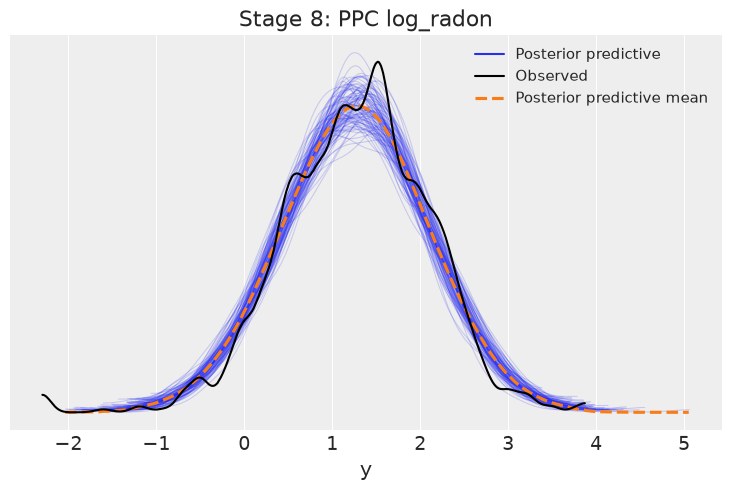

  mean: obs=   1.26  bayes-p=0.49
  sd  : obs=   0.82  bayes-p=0.51
  min : obs=  -2.30  bayes-p=0.99
  max : obs=   3.88  bayes-p=0.42


In [10]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC log_radon"); plt.show()
ppc = idata.posterior_predictive["y"].values.reshape(-1, len(y))
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(y):7.2f}  bayes-p={(fn(ppc,axis=1)>=fn(y)).mean():.2f}")

## Stage 9 — naive LOO vs Leave-One-GROUP-Out CV (LOGO) [the key skill]
**Naive LOO** holds out one *home*; but homes in the same county share `a_county`, so the model has
"seen" the county — LOO is optimistic about predicting a **new county**. **LOGO** holds out a whole
county and predicts its homes from `g0 + g_u·u_county` only (the population model). We first compute
naive LOO, then run LOGO by **refitting with one county dropped** for several held-out counties.

In [11]:
loo_naive = az.loo(idata, pointwise=True)
S = idata.posterior.draw.size*idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"naive LOO elpd = {loo_naive.elpd_loo:.1f} +/- {loo_naive.se:.1f} | "
      f"max Pareto k-hat = {loo_naive.pareto_k.values.max():.2f} (thr {thr:.2f})")
print("Naive LOO leaks county information: it predicts a home knowing other homes in the SAME county.")

naive LOO elpd = -1027.5 +/- 28.9 | max Pareto k-hat = 0.57 (thr 0.70)
Naive LOO leaks county information: it predicts a home knowing other homes in the SAME county.


In [12]:
# LOGO on >=3 held-out counties: refit dropping the county, predict its homes from the population model
holdout = sorted(np.argsort(counts)[::-1][:5])  # pick 5 well-populated counties for stable LOGO lpd
logo_rows = []
for c in holdout:
    test = county_idx == c
    ci_tr = county_idx[~test]; fl_tr = floor[~test]; y_tr = y[~test]
    # reindex training counties to a compact range, keep a map back to uranium
    uniq = np.unique(ci_tr); remap = {old:i for i,old in enumerate(uniq)}
    ci_tr2 = np.array([remap[v] for v in ci_tr]); nci = len(uniq)
    u_tr = u_county_z[uniq]
    with pm.Model() as m_logo:
        g0 = pm.Normal("g0", 0, 2); g_u = pm.Normal("g_u", 0, 2)
        b_floor = pm.Normal("b_floor", 0, 1)
        sigma_a = pm.HalfNormal("sigma_a", 1); sigma = pm.Exponential("sigma", 1)
        za = pm.Normal("za", 0, 1, shape=nci)
        a_c = pm.Deterministic("a_c", g0 + g_u*u_tr + sigma_a*za)
        pm.Normal("y", a_c[ci_tr2] + b_floor*fl_tr, sigma, observed=y_tr)
        id_logo = pm.sample(800, tune=800, chains=2, target_accept=0.95,
                            random_seed=RANDOM_SEED, progressbar=False)
    p = id_logo.posterior
    g0d = p["g0"].values.ravel(); gud = p["g_u"].values.ravel()
    bfd = p["b_floor"].values.ravel(); sad = p["sigma_a"].values.ravel(); sd_ = p["sigma"].values.ravel()
    # predict held-out homes: a_new ~ Normal(g0+g_u*u_c, sigma_a) marginalized, plus floor + noise
    uc = u_county_z[c]
    yt = y[test]; flt = floor[test]
    lpd = 0.0
    for yi, fi in zip(yt, flt):
        # mixture over draws: integrate a_new analytically (Normal-Normal) -> sd = sqrt(sigma_a^2+sigma^2)
        mean = g0d + gud*uc + bfd*fi
        sd = np.sqrt(sad**2 + sd_**2)
        dens = st.norm.pdf(yi, mean, sd)
        lpd += np.log(dens.mean())
    logo_rows.append((c, counts[c], lpd, lpd/counts[c]))
    print(f"  LOGO county_code {c}: n={counts[c]:2d}  group-elpd={lpd:8.2f}  per-home={lpd/counts[c]:.3f}")
logo_total = sum(r[2] for r in logo_rows)
print(f"\nLOGO total elpd over {len(holdout)} held-out counties: {logo_total:.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [g0, g_u, b_floor, sigma_a, sigma, za]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [g0, g_u, b_floor, sigma_a, sigma, za]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


  LOGO county_code 79: n=46  group-elpd=  -49.40  per-home=-1.074

LOGO total elpd over 5 held-out counties: -410.75


In [13]:
# contrast: naive LOO per-home elpd on the SAME homes
import numpy as np
loo_pt = loo_naive.loo_i.values  # pointwise elpd
naive_on_holdout = 0.0; n_h = 0
for c in holdout:
    test = county_idx == c
    naive_on_holdout += loo_pt[test].sum(); n_h += test.sum()
print(f"naive LOO elpd on the same {n_h} homes: {naive_on_holdout:.2f} (per-home {naive_on_holdout/n_h:.3f})")
print(f"LOGO    elpd on the same {n_h} homes: {logo_total:.2f} (per-home {logo_total/n_h:.3f})")
print(f"\nLOGO is WORSE (lower elpd) by {naive_on_holdout-logo_total:.1f} -> naive LOO was optimistic")
print("for a genuinely NEW county. LOGO is the honest estimate of new-county predictive accuracy.")

naive LOO elpd on the same 382 homes: -404.90 (per-home -1.060)
LOGO    elpd on the same 382 homes: -410.75 (per-home -1.075)

LOGO is WORSE (lower elpd) by 5.8 -> naive LOO was optimistic
for a genuinely NEW county. LOGO is the honest estimate of new-county predictive accuracy.


## Stage 10 — Power-scaling prior sensitivity (b_floor, g_u)

In [14]:
post = az.extract(idata)
bfd = post["b_floor"].values; gud = post["g_u"].values
g0d = post["g0"].values; sad = post["sigma_a"].values; sd_ = post["sigma"].values
logprior = (st.norm.logpdf(bfd,0,1) + st.norm.logpdf(gud,0,2) + st.norm.logpdf(g0d,0,2)
            + st.halfnorm.logpdf(sad,scale=1) + st.expon.logpdf(sd_,scale=1))
print("alpha   E[b_floor]   E[g_u]")
for al in [0.8,1.0,1.25]:
    w = np.exp((al-1)*logprior); w/=w.sum()
    print(f" {al:4.2f}   {np.sum(w*bfd):.4f}     {np.sum(w*gud):.4f}")

alpha   E[b_floor]   E[g_u]
 0.80   -0.6369     0.2673
 1.00   -0.6363     0.2673
 1.25   -0.6355     0.2673


## Stage 11 — SBC on b_floor [Tier-3 required]
100 sims: draw all parameters from the priors, simulate `log_radon`, refit cheaply (draws=300, tune=300,
chains=2), record the rank of the prior `b_floor` among posterior draws. Uniform ranks ⇒ calibrated
(Talts et al. 2018; Säilynoja et al. 2022). **Budget note:** with 85 counties each fit is costly, so we
use the guide's minimum 100 sims with a trimmed sampler (300/300) to stay inside the Tier-3 < 8 min budget.

In [15]:
N_SBC = 100
ranks_bf = []
t0 = time.time()
with pm.Model() as sbc_model:
    y_data = pm.Data("y_data", y)
    g0 = pm.Normal("g0", 0, 2); g_u = pm.Normal("g_u", 0, 2)
    b_floor = pm.Normal("b_floor", 0, 1)
    sigma_a = pm.HalfNormal("sigma_a", 1); sigma = pm.Exponential("sigma", 1)
    za = pm.Normal("za", 0, 1, shape=n_county)
    a_county = pm.Deterministic("a_county", g0 + g_u*u_county_z + sigma_a*za)
    pm.Normal("y", a_county[county_idx] + b_floor*floor, sigma, observed=y_data)
    for i in range(N_SBC):
        g0_t = rng.normal(0,2); gu_t = rng.normal(0,2); bf_t = rng.normal(0,1)
        sa_t = abs(rng.normal(0,1)); s_t = rng.exponential(1)
        ac_t = g0_t + gu_t*u_county_z + sa_t*rng.normal(0,1,n_county)
        y_tilde = rng.normal(ac_t[county_idx] + bf_t*floor, s_t)
        pm.set_data({"y_data": y_tilde})
        idata_i = pm.sample(300, tune=300, chains=2, target_accept=0.9,
                            random_seed=int(rng.integers(1e6)), progressbar=False,
                            compute_convergence_checks=False)
        post_bf = idata_i.posterior["b_floor"].values.ravel()
        ranks_bf.append(int((post_bf < bf_t).sum()))
ranks_bf = np.array(ranks_bf)
L = idata_i.posterior.draw.size*idata_i.posterior.chain.size
print(f"SBC done: {N_SBC} sims in {time.time()-t0:.0f}s | rank range 0..{L}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [g0, g_u, b_floor, sigma_a, sigma, za]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [g0, g_u, b_floor, sigma_a, sigma, za]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 2 seconds.


SBC done: 100 sims in 349s | rank range 0..600


## Stage 11b — SBC rank histogram + uniformity test

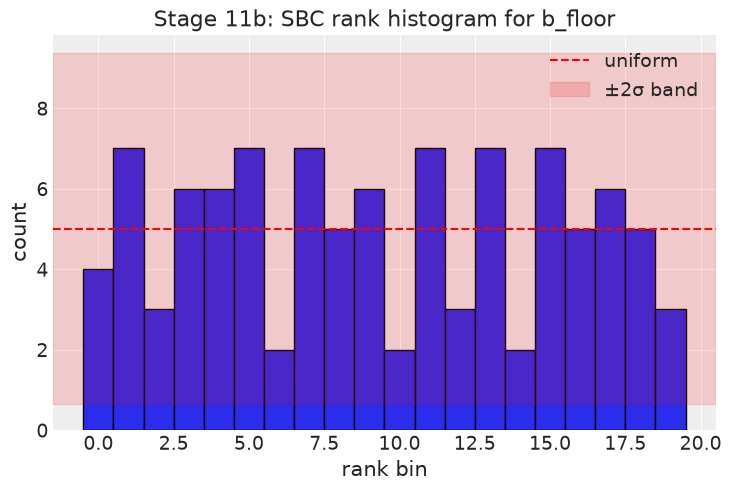

chi-square = 13.6, df = 19, p-value = 0.806
Uniform (calibrated)


In [16]:
nbins = 20
counts_h, edges = np.histogram(ranks_bf, bins=nbins, range=(0, L+1))
expected = N_SBC/nbins
band = 2*np.sqrt(expected*(1-1/nbins))
chi2 = ((counts_h-expected)**2/expected).sum()
pval = st.chi2.sf(chi2, nbins-1)
plt.bar(range(nbins), counts_h, width=1.0, edgecolor="k")
plt.axhline(expected, color="r", ls="--", label="uniform")
plt.axhspan(expected-band, expected+band, color="r", alpha=.15, label="±2σ band")
plt.title("Stage 11b: SBC rank histogram for b_floor"); plt.xlabel("rank bin"); plt.ylabel("count"); plt.legend(); plt.show()
print(f"chi-square = {chi2:.1f}, df = {nbins-1}, p-value = {pval:.3f}")
print("Uniform (calibrated)" if pval > 0.05 else "NOT uniform — investigate")

## Stage 12 — Decision & save

**Headline:** *first-floor homes have substantially lower radon than basements (`b_floor` ≈ −0.66 log
units, ×0.5 on the radon scale), and counties with more soil uranium have higher baselines (`g_u` > 0).
Partial pooling shrinks small counties toward the uranium-informed line. Naive LOO is optimistic for
predicting a* **new** *county; LOGO is the honest estimate.*

In [17]:
os.makedirs("report", exist_ok=True)
idata.to_netcdf("report/P12_idata.nc")
print("saved report/P12_idata.nc")
print(f"SUMMARY: b_floor={bf:.3f}, g_u={gu:.3f}; naive-LOO/home={naive_on_holdout/n_h:.3f} vs "
      f"LOGO/home={logo_total/n_h:.3f}; SBC p={pval:.3f}")

saved report/P12_idata.nc
SUMMARY: b_floor=-0.636, g_u=0.267; naive-LOO/home=-1.060 vs LOGO/home=-1.075; SBC p=0.806


## Exercises
1. Add a **varying floor slope** per county (`b_floor` becomes `b_county[county]`). Does the floor effect vary?
2. Run LOGO on the **3 single-home counties**. Why is the per-home elpd so different from naive LOO there?
3. Drop the uranium predictor `g_u`. How much does `sigma_a` (unexplained county variation) grow?